# Food Truck

Here we will implement linear regression with one variable to predict profits for a food truck.  <br>


Suppose you are the CEO of a restaurant franchise and are considering different cities for opening a new outlet. The chain already has trucks in various cities and you have data for profits and populations from the cities. <br>


The file food_truck.txt  contains the dataset for our linear regression exercise.  <br>


The first column is the population of a city and the second column is the profit of a food truck in that city. A negative value for profit indicates a loss. <br>


So. let's start. <br>

## Importing Libraries

In [1]:
# import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Importing the dataset

In [2]:
data = pd.read_csv(r'../food_truck.txt', header = None, delimiter = ",") #read from dataset
X = data.iloc[:,0] # read first column, will be put in a 'series' variable
print('X.shape: ', X.shape)
y = data.iloc[:,1] # read second column, will be put in a 'series' variable
print('y.shape: ', y.shape)
sample_quantity = len(y) # number of training example (97)
print('Number of samples:', sample_quantity)
print(data.head()) # view first few rows of the data

X.shape:  (97,)
y.shape:  (97,)
Number of samples: 97
        0        1
0  6.1101  17.5920
1  5.5277   9.1302
2  8.5186  13.6620
3  7.0032  11.8540
4  5.8598   6.8233


## Visualization of the data

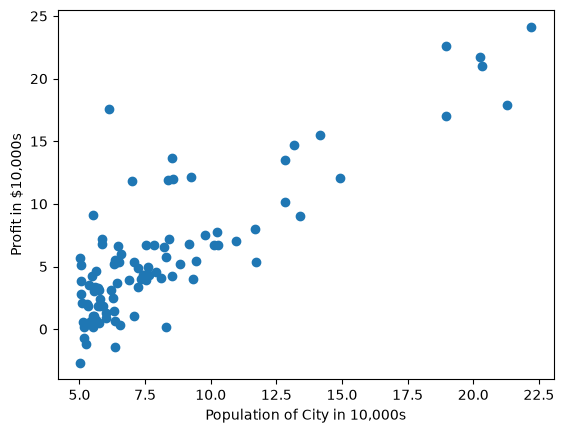

In [3]:
# FEEL FREE TO IMPROVE THE PLOT

# Reading and Plotting the data
# Before starting on any task, try to visualize the data. 
# You can use a scatter plot to visualize this data, since it has only two properties to plot (profit and population).
# For multidimensional data : cannot be plotted on a 2-d or 3-d plot. 

plt.scatter(X, y)
plt.xlabel('Population of City in 10,000s')
plt.ylabel('Profit in $10,000s')
plt.show()

Initializing and converting into an nparray, we want to make use of array manipulations (dot product). <br>

In the following lines, we add another dimension to our data to accommodate the intercept term, we want to find the best values for Theta0 and Theta1 for the function:  <br>

**y = Theta0 + Theta1 * x** <br> 

by getting the error/cost as small as possible.  <br>


We also initialize the initial parameters theta to 0 and the learning rate alpha to 0.01. <br>

## Reshaping the data

In [4]:
print(type(X)) # should be a pd.Series()
X = X.to_numpy()[:,np.newaxis] # convert pd.Series() to an np.ndarray
y = y.to_numpy()[:,np.newaxis] # convert pd.Series() to an np.ndarray

print('X.shape: ', X.shape)
print('y.shape: ', y.shape)

# Will generate a warning:
# Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.

# # Better w/o warning
# X = X.to_numpy()[:,np.newaxis] # convert pd.Series() to an np.ndarray
# y = y.to_numpy()[:,np.newaxis] # convert pd.Series() to an np.ndarray

theta = np.zeros([2,1]) # start off with a (0, 0) array
iteration = 100000 # 
learning_rate = 0.01 # magic number, defines the increase in change in Theta in every iteration we take
# apply the trick we saw in the classroom of 'all ones' for x0, so that we can use matrix multiplication 

#SOLUTION:

ones = np.ones((sample_quantity,1))
X_ones = np.hstack((ones, X)) 
print('theta: ', theta)
print('X.shape: ', X_ones.shape)

<class 'pandas.Series'>
X.shape:  (97, 1)
y.shape:  (97, 1)
theta:  [[0.]
 [0.]]
X.shape:  (97, 2)


## Computting the cost (or error)

In [5]:
def computeCost(X_ones, y, theta):
    # We are going to calculate the MSE (Mean Square Error). NOT the RMSE (Root Mean Square Error)
    #
    #SOLUTION
    local_cost = np.dot(X_ones, theta) - y
    #"local_cost" represents the individual squared differences between predicted and actual values for each data point
    total_cost = np.sum(np.power(local_cost, 2)) / (2*sample_quantity)
    #"total_cost" represents the overall Mean Squared Error (MSE) for the entire dataset
    return total_cost

In [6]:
cost =  computeCost(X_ones, y, theta)
print(cost)
# You get a cost of 32.072733877455676

32.072733877455676


## Creating the Optimizer

In [7]:
def gradientDescent(X_ones, y, theta, learning_rate, iteration):
    #SOLUTION
    # Implement the gradient descent algorithm
    for _ in range(iteration):
    # Compute predictions (hypothesis)
        y_pred = X_ones.dot(theta)
        
        # Compute the error (difference between predictions and actual values)
        error = y_pred - y
        
        # Compute the gradient of the cost function with respect to theta
        gradient = 2 * X_ones.T.dot(error) / len(X_ones)
        
        # Update theta using the gradient and learning rate
        theta -= learning_rate * gradient
    #
    return theta

In [8]:
theta_refined = gradientDescent(X_ones, y, theta, learning_rate, iteration)
print(theta)
###  This should result in
#  [[-3.89578088]
#  [ 1.19303364]]
### 

[[-3.89578088]
 [ 1.19303364]]


## Checking the final cost (or error)

In [9]:
cost_refined =  computeCost(X_ones, y, theta_refined)
print(cost_refined)

4.476971375975179


In [10]:
# Can we improve on these results?
# Try with different values for the number of iterations and with different learning rates
# Try eg with as number of iterations: 500, 1500, 5000, 10000, 100000,...
# Try a different learning rate: 0.1, 0.03, 0.01, 0.003, 0.001, ...


## Vizualization of the Linear Regression

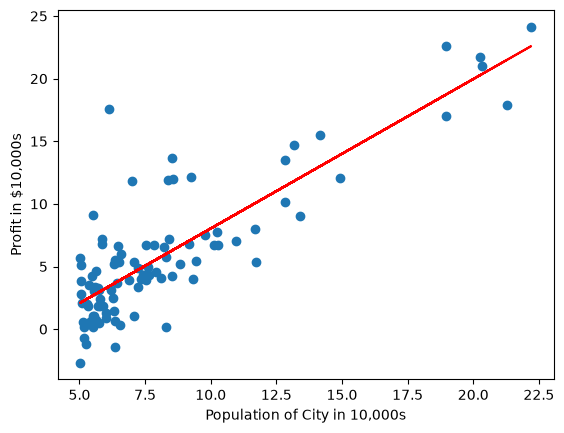

In [11]:
plt.scatter(X_ones[:,1], y)
plt.xlabel('Population of City in 10,000s')
plt.ylabel('Profit in $10,000s')
plt.plot(X_ones[:,1], np.dot(X_ones, theta), color = 'red')
plt.show()

## Predicting

In [12]:
# Now you can use the trained model to make predictions on new data
#REPLACE: value_to_be_predicted and ?

values_to_be_predicted = [6000, 10000, 20000, 30000]
for value_to_be_predicted in values_to_be_predicted:
    new_X = np.array([[value_to_be_predicted]])
    new_X_b = np.c_[np.ones((1, 1)), new_X] 
    predicted_y = new_X_b.dot(theta_refined)
    print(f"Predicted y for X={value_to_be_predicted}:", predicted_y[0, 0])

Predicted y for X=6000: 7154.306084259215
Predicted y for X=10000: 11926.440661017565
Predicted y for X=20000: 23856.777102913442
Predicted y for X=30000: 35787.11354480932
